# Semana 2 — Feature Engineering + Pipeline

**Objetivo:** Crear variables nuevas que el modelo no puede inferir solo, y encapsular todas las transformaciones en un `Pipeline` de sklearn.  



---

## 0. Cargar datos y reproducir limpieza de semana 1

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# --- Limpieza reproducida de semana 1 ---
df = pd.read_csv('telco.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)
df = df.drop(columns=['customerID', 'Churn'])  # ID no aporta; usamos Churn_bin

print(f'Dataset listo: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.head(3)

Dataset listo: 7,043 filas x 20 columnas


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_bin
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


---
## 1. Feature Engineering manual

El EDA de la semana 1 nos dio pistas. Ahora las convertimos en variables concretas.



In [4]:
def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    """
    Crea nuevas variables a partir del conocimiento del dominio.
    Recibe y devuelve un DataFrame — no modifica el original.
    """
    d = df.copy()

    # 1. Cliente nuevo (primeros 6 meses = período crítico de churn)
    #    Hipótesis: los primeros meses el cliente aún evalúa si el servicio vale
    d['es_cliente_nuevo'] = (d['tenure'] <= 6).astype(int)

    # 2. Ratio cargos mensuales / tenure
    #    Hipótesis: clientes que pagan mucho en poco tiempo tienen más riesgo
    #    Evitamos división por 0 sumando 1 al denominador
    d['cargo_por_mes'] = d['MonthlyCharges'] / (d['tenure'] + 1)

    # 3. Número de servicios contratados
    #    Hipótesis: más servicios = más "atado" al proveedor = menos churn
    servicios = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    d['num_servicios'] = d[servicios].apply(
        lambda row: sum(row == 'Yes'), axis=1
    )

    # 4. Cliente sin servicios extra (solo línea básica)
    #    Hipótesis: clientes con mínimo compromiso tienen más probabilidad de irse
    d['sin_servicios_extra'] = (d['num_servicios'] == 0).astype(int)

    # 5. Flag de contrato mensual (la variable más predictiva del EDA)
    d['contrato_mensual'] = (d['Contract'] == 'Month-to-month').astype(int)

    # 6. Diferencia entre cargo mensual y promedio del grupo de contrato
    #    Hipótesis: pagar más que el promedio de tu tipo de contrato = insatisfacción
    media_por_contrato = d.groupby('Contract')['MonthlyCharges'].transform('mean')
    d['cargo_sobre_media_contrato'] = d['MonthlyCharges'] - media_por_contrato

    return d


df = feature_engineering(df)

nuevas = ['es_cliente_nuevo', 'cargo_por_mes', 'num_servicios',
          'sin_servicios_extra', 'contrato_mensual', 'cargo_sobre_media_contrato']

print('Variables nuevas creadas:')
print(df[nuevas + ['Churn_bin']].head(8).to_string(index=False))

Variables nuevas creadas:
 es_cliente_nuevo  cargo_por_mes  num_servicios  sin_servicios_extra  contrato_mensual  cargo_sobre_media_contrato  Churn_bin
                1      14.925000              1                    0                 1                  -36.548490          0
                0       1.627143              3                    0                 0                   -8.098608          0
                1      17.950000              3                    0                 1                  -12.548490          1
                0       0.919565              3                    0                 0                  -22.748608          0
                1      23.566667              1                    0                 1                    4.301510          1
                0      11.072222              4                    0                 1                   33.251510          1
                0       3.873913              3                    0                 1      

---
## 2. Validar que las nuevas variables tienen señal

Antes de meterlas al modelo, comprueba que realmente discriminan.  
Si no discriminan, no las incluyas — añadir ruido perjudica al modelo.

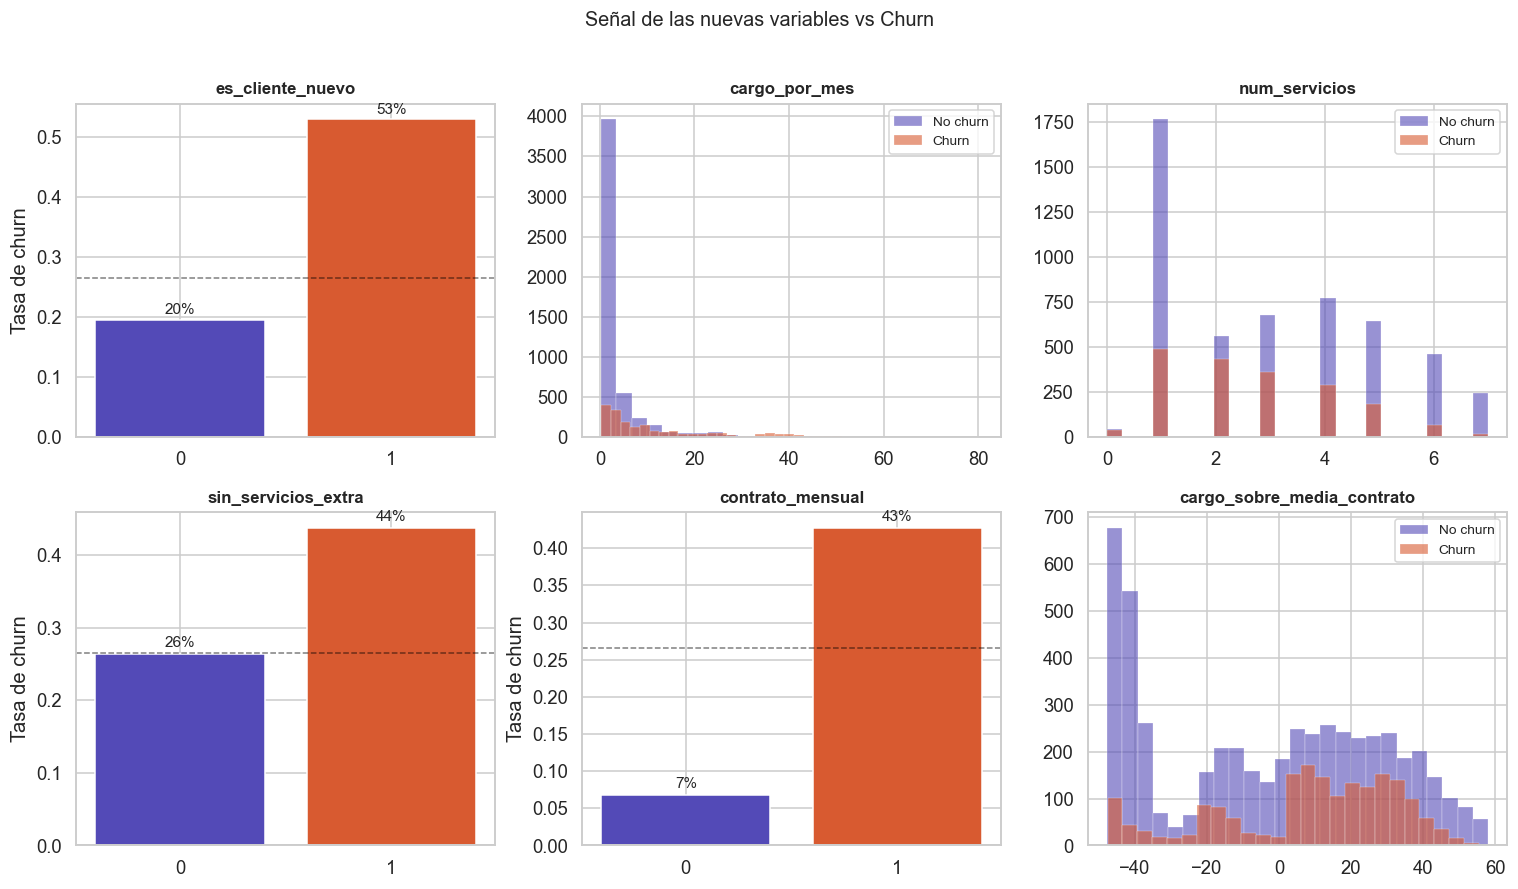

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, nuevas):
    if df[col].nunique() == 2:  # binaria
        churn_rate = df.groupby(col)['Churn_bin'].mean()
        bars = ax.bar(churn_rate.index.astype(str), churn_rate.values,
                      color=['#534AB7', '#D85A30'], edgecolor='white')
        ax.axhline(df['Churn_bin'].mean(), color='black',
                   linestyle='--', linewidth=1, alpha=0.5)
        for bar, val in zip(bars, churn_rate.values):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                    f'{val:.0%}', ha='center', fontsize=10)
        ax.set_ylabel('Tasa de churn')
    else:  # continua
        for label, color in [('No churn', '#534AB7'), ('Churn', '#D85A30')]:
            mask = df['Churn_bin'] == (1 if label == 'Churn' else 0)
            ax.hist(df.loc[mask, col], bins=25, alpha=0.6,
                    label=label, color=color, edgecolor='white', linewidth=0.3)
        ax.legend(fontsize=9)
    ax.set_title(col, fontsize=11, fontweight='bold')

plt.suptitle('Señal de las nuevas variables vs Churn', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('plot_06_nuevas_variables.png', bbox_inches='tight')
plt.show()

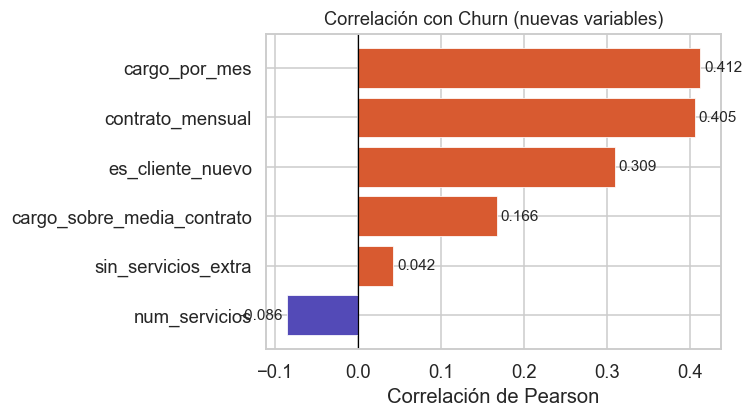


→ contrato_mensual y es_cliente_nuevo tienen la señal más fuerte — confirma el EDA


In [6]:
# Correlación de las nuevas variables con Churn
correlaciones = df[nuevas + ['Churn_bin']].corr()['Churn_bin'].drop('Churn_bin').sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#D85A30' if v > 0 else '#534AB7' for v in correlaciones.values]
bars = ax.barh(correlaciones.index, correlaciones.values,
               color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, correlaciones.values):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=10)
ax.set_title('Correlación con Churn (nuevas variables)', fontsize=12)
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.savefig('plot_07_correlacion_nuevas.png', bbox_inches='tight')
plt.show()

print('\n→ contrato_mensual y es_cliente_nuevo tienen la señal más fuerte — confirma el EDA')

---
## 3. Dividir train / test ANTES de cualquier transformación

> **Buena práctica crítica:** el set de test debe ser completamente invisible durante
> el entrenamiento y la transformación. Si calculas la media del dataset completo
> para imputar nulos, estás "filtrando" información del futuro al pasado — data leakage.
> El Pipeline de sklearn previene esto automáticamente.

In [7]:
X = df.drop(columns=['Churn_bin'])
y = df['Churn_bin']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # mantiene la proporción de churn en ambos sets
)

print(f'Train: {X_train.shape[0]:,} filas  |  Test: {X_test.shape[0]:,} filas')
print(f'Tasa de churn en train: {y_train.mean():.1%}')
print(f'Tasa de churn en test:  {y_test.mean():.1%}')
print('\n→ stratify=y asegura que ambos sets tienen ~26% de churn')

Train: 5,634 filas  |  Test: 1,409 filas
Tasa de churn en train: 26.5%
Tasa de churn en test:  26.5%

→ stratify=y asegura que ambos sets tienen ~26% de churn


---
## 4. Construcción del Pipeline

Un Pipeline encadena transformaciones y el modelo final en un solo objeto.  
Cuando llames a `pipeline.fit(X_train)`, aplica todas las transformaciones  
aprendidas solo en train. Cuando llames a `pipeline.predict(X_test)`,  
aplica las mismas transformaciones sin recalcular nada.

In [8]:
# ── Definir qué columnas son numéricas y cuáles categóricas ──

# Excluimos las binarias que ya creamos (0/1) — no necesitan transformación
binary_created = ['es_cliente_nuevo', 'sin_servicios_extra',
                  'contrato_mensual', 'SeniorCitizen']

numeric_features = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'cargo_por_mes', 'num_servicios', 'cargo_sobre_media_contrato'
]

categorical_features = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

print(f'Numéricas:     {len(numeric_features)} columnas')
print(f'Categóricas:   {len(categorical_features)} columnas')
print(f'Binarias (ya OK): {len(binary_created)} columnas')

Numéricas:     6 columnas
Categóricas:   15 columnas
Binarias (ya OK): 4 columnas


In [9]:
# ── Sub-pipeline para columnas numéricas ──
# 1. Imputa nulos con la mediana (más robusto que la media ante outliers)
# 2. Escala a media=0 desv=1 (necesario para modelos lineales y KNN)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# ── Sub-pipeline para columnas categóricas ──
# 1. Imputa nulos con el valor más frecuente
# 2. One-Hot Encoding: convierte cada categoría en columna binaria
#    handle_unknown='ignore' evita errores si aparece una categoría nueva en producción
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ── Combinar ambos sub-pipelines con ColumnTransformer ──
# remainder='passthrough' deja pasar las columnas binarias sin tocarlas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='passthrough'  # pasa binary_created tal cual
)

print('Preprocessor construido correctamente.')
print('Todavía no transformó nada — eso ocurre cuando llamemos a .fit()')

Preprocessor construido correctamente.
Todavía no transformó nada — eso ocurre cuando llamemos a .fit()


In [10]:
# ── Probar el preprocessor con un modelo dummy ──
# Usamos DummyClassifier para verificar que el Pipeline funciona
# antes de poner el modelo real (semana 3)
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

pipeline_dummy = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='stratified', random_state=42))
])

pipeline_dummy.fit(X_train, y_train)
y_pred_dummy = pipeline_dummy.predict(X_test)

print('=== BASELINE DUMMY (predice aleatoriamente respetando proporciones) ===')
print(classification_report(y_test, y_pred_dummy, target_names=['No churn', 'Churn']))
print('→ Este es el piso mínimo. Cualquier modelo real debe superar esto.')

=== BASELINE DUMMY (predice aleatoriamente respetando proporciones) ===
              precision    recall  f1-score   support

    No churn       0.74      0.74      0.74      1035
       Churn       0.29      0.29      0.29       374

    accuracy                           0.62      1409
   macro avg       0.52      0.52      0.52      1409
weighted avg       0.62      0.62      0.62      1409

→ Este es el piso mínimo. Cualquier modelo real debe superar esto.


---
## 5. Inspeccionar el resultado de la transformación

Es buena práctica revisar cómo quedaron los datos después del Pipeline  
para detectar errores antes de modelar.

In [11]:
# Aplicar solo el preprocessor para inspeccionar
preprocessor_solo = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='passthrough'
)

X_train_transformed = preprocessor_solo.fit_transform(X_train)
X_test_transformed  = preprocessor_solo.transform(X_test)

# Obtener nombres de columnas resultantes
ohe_cols = preprocessor_solo.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_cols) + binary_created

X_train_df = pd.DataFrame(X_train_transformed, columns=all_feature_names)

print(f'Shape después del Pipeline: {X_train_df.shape}')
print(f'Columnas originales: {X.shape[1]}  →  Columnas transformadas: {X_train_df.shape[1]}')
print(f'\nNulos restantes: {X_train_df.isnull().sum().sum()} (debe ser 0)')
print('\nPrimeras 3 filas (numéricas escaladas):')
print(X_train_df[numeric_features].head(3).round(3).to_string())

Shape después del Pipeline: (5634, 51)
Columnas originales: 25  →  Columnas transformadas: 51

Nulos restantes: 0 (debe ser 0)

Primeras 3 filas (numéricas escaladas):
   tenure  MonthlyCharges  TotalCharges  cargo_por_mes  num_servicios  cargo_sobre_media_contrato
0   0.102          -0.522        -0.263         -0.502          0.022                      -0.578
1  -0.712           0.337        -0.505         -0.119         -0.518                       0.284
2  -0.793          -0.809        -0.751         -0.326          0.022                      -0.679


In [12]:
# Verificar que el escalado es correcto (media ~0, std ~1)
print('Estadísticas de columnas numéricas tras escalado (deben ser ~0 y ~1):')
stats = X_train_df[numeric_features].agg(['mean', 'std']).round(3)
print(stats.to_string())

Estadísticas de columnas numéricas tras escalado (deben ser ~0 y ~1):
      tenure  MonthlyCharges  TotalCharges  cargo_por_mes  num_servicios  cargo_sobre_media_contrato
mean    -0.0            -0.0          -0.0            0.0           -0.0                        -0.0
std      1.0             1.0           1.0            1.0            1.0                         1.0


---
## 6. Guardar los objetos para semana 3

In [13]:
import joblib

# Guardar los splits y el preprocessor
joblib.dump(X_train, 'X_train.pkl')
joblib.dump(X_test,  'X_test.pkl')
joblib.dump(y_train, 'y_train.pkl')
joblib.dump(y_test,  'y_test.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')

# Guardar la lista de features (útil en semana 8 para el deploy)
import json
feature_config = {
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'binary_created': binary_created,
    'nuevas_variables': nuevas
}
with open('feature_config.json', 'w') as f:
    json.dump(feature_config, f, indent=2)

print('Archivos guardados:')
print('  X_train.pkl, X_test.pkl, y_train.pkl, y_test.pkl')
print('  preprocessor.pkl')
print('  feature_config.json')
print('\n→ Descárgalos con: files.download("nombre.pkl")')

Archivos guardados:
  X_train.pkl, X_test.pkl, y_train.pkl, y_test.pkl
  preprocessor.pkl
  feature_config.json

→ Descárgalos con: files.download("nombre.pkl")
